# 04 — Why can $\phi^u_{US}$ rise? Spillover and funding-ratio sweeps

This notebook implements a controlled diagnostic for the increasing U.S. production-labour share on the all-`u` path. Recall that $\phi_{US}$ is skilled labour in production, while $1-\phi_{US}$ is the R&D share.

The experiment changes one unbalanced-regime exponent at a time:

- lower $\nu_u$, holding $\xi_u=2.25$ fixed;
- raise $\xi_u$, holding $\nu_u=1.75$ fixed.

All other AHP calibration parameters remain fixed, including $\nu_b=\xi_W=0$. The notebook reports the exact endpoint accounting decomposition, the funding ratio $\zeta_t=Q^u_{US,t}/(\beta e^u_{US,t})$, knowledge, the tail exponents $\kappa_D$ and $\kappa_S$, and all-`u` versus switch-to-`b` labour allocations for both countries. This is a finite-horizon comparative-static diagnostic, not a new long-horizon theorem certificate.

In [1]:
using Pkg

const NB04_DIRNAME = "Two_country_proudction_zero_nu_b"
const NB04_MODEL_CANDIDATES = unique(normpath.([
    joinpath(pwd(), NB04_DIRNAME, "TwoCountryProductionOLG.jl"),
    joinpath(pwd(), "Codes", NB04_DIRNAME, "TwoCountryProductionOLG.jl"),
    joinpath(dirname(pwd()), NB04_DIRNAME, "TwoCountryProductionOLG.jl"),
]))
nb04_model_idx = findfirst(isfile, NB04_MODEL_CANDIDATES)
isnothing(nb04_model_idx) && error("Cannot find the zero-nu-b solver. Checked:\n" * join(NB04_MODEL_CANDIDATES, "\n"))
const NB04_MODEL_FILE = NB04_MODEL_CANDIDATES[nb04_model_idx]
const NB04_CODES_ROOT = dirname(dirname(NB04_MODEL_FILE))
Pkg.activate(NB04_CODES_ROOT)
include(NB04_MODEL_FILE)

using Plots, LaTeXStrings, Printf, Markdown
gr()

const NB04_OUTDIR = joinpath(dirname(NB04_MODEL_FILE), "outputs_zero_nu_b", "04_phi_spillover_funding_sweeps")
mkpath(NB04_OUTDIR)
@info "Loaded zero-exponent solver for Notebook 04" NB04_MODEL_FILE NB04_OUTDIR

  Activating project at `~/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes`
┌ Info: Loaded zero-exponent solver for Notebook 04
│   NB04_MODEL_FILE = "/Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_proudction_zero_nu_b/TwoCountryProductionOLG.jl"
└   NB04_OUTDIR = "/Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_proudction_zero_nu_b/outputs_zero_nu_b/04_phi_spillover_funding_sweeps"


## 1. Calibration and one-parameter experiment

The common horizon is deliberately $T=30$: it is long enough to identify the finite-path sign and short enough that every counterfactual can be independently re-solved and audited. The baseline is included once in the solve set and reused in both plotted sweep families.

In [2]:
const NB04_T = 30
const NB04_BRANCH_ITERS = 500
const NB04_RESID_TOL = 1e-5

const NB04_CASES = [
    (id="baseline", sweep="baseline", label="baseline: xi=2.25, nu=1.75", ξ_u=2.25, ν_u=1.75),
    (id="nu_1_50", sweep="lower_nu", label="lower nu: 1.50", ξ_u=2.25, ν_u=1.50),
    (id="nu_1_25", sweep="lower_nu", label="lower nu: 1.25", ξ_u=2.25, ν_u=1.25),
    (id="xi_2_50", sweep="raise_xi", label="raise xi: 2.50", ξ_u=2.50, ν_u=1.75),
    (id="xi_2_75", sweep="raise_xi", label="raise xi: 2.75", ξ_u=2.75, ν_u=1.75),
]

function nb04_params(case)
    ProductionParams(
        T_max=NB04_T, n_buffer=0, branch_iters=NB04_BRANCH_ITERS,
        common_world_growth=false, do_global_polish=false,
        β=0.45, γ=0.25, π_persist=0.75,
        a_US=0.20, ϑ_US=0.85,
        a_W=0.06, H_W=3.0, L_W=3.0,
        A_X_US_u=15.0, A_L_US_u=1.5,
        ν_b=0.0, ν_u=case.ν_u, ξ_u=case.ξ_u, ξ_W=0.0,
        ω̄=0.50, ω̄_star=0.25,
        κ=1.00, χ=0.0002, η=0.010,
    )
end

for case in NB04_CASES
    p = nb04_params(case)
    @assert p.ξ_u > p.ν_u > p.ν_b == 0.0
    @assert p.ξ_W == 0.0
end

NB04_CASES

5-element Vector{@NamedTuple{id::String, sweep::String, label::String, ξ_u::Float64, ν_u::Float64}}:
 (id = "baseline", sweep = "baseline", label = "baseline: xi=2.25, nu=1.75", ξ_u = 2.25, ν_u = 1.75)
 (id = "nu_1_50", sweep = "lower_nu", label = "lower nu: 1.50", ξ_u = 2.25, ν_u = 1.5)
 (id = "nu_1_25", sweep = "lower_nu", label = "lower nu: 1.25", ξ_u = 2.25, ν_u = 1.25)
 (id = "xi_2_50", sweep = "raise_xi", label = "raise xi: 2.50", ξ_u = 2.5, ν_u = 1.75)
 (id = "xi_2_75", sweep = "raise_xi", label = "raise xi: 2.75", ξ_u = 2.75, ν_u = 1.75)

## 2. Independent equilibrium solves

Each case is solved from the model's own initial guess. No counterfactual inherits another case's equilibrium path.

In [3]:
nb04_solutions = Dict{String,Any}()
for case in NB04_CASES
    @printf("Solving %-10s  xi_u=%.2f  nu_u=%.2f ... ", case.id, case.ξ_u, case.ν_u)
    started = time()
    result = run_production_simulation(nb04_params(case); verbose=false)
    nb04_solutions[case.id] = result
    @printf("%.2fs; converged=%s; max u residual=%.3e\n", time()-started, result.branch_converged, result.max_u_residual)
end
nothing

Solving baseline    xi_u=2.25  nu_u=1.75 ... 4.29s; converged=true; max u residual=1.032e-07


Solving nu_1_50     xi_u=2.25  nu_u=1.50 ... 0.01s; converged=true; max u residual=1.151e-07
Solving nu_1_25     xi_u=2.25  nu_u=1.25 ... 0.02s; converged=true; max u residual=1.187e-07
Solving xi_2_50     xi_u=2.50  nu_u=1.75 ... 0.75s; converged=true; max u residual=1.217e-07


Solving xi_2_75     xi_u=2.75  nu_u=1.75 ... 0.02s; converged=true; max u residual=1.080e-07


## 3. Exact mechanism accounting

Define

$$r_t=\frac{w_{L,t}L}{w_{H,t}H}=K_uN_{US,t}^{\psi_{US}}(\phi^u_{US,t})^{\rho_{US}},$$

where $\psi_{US}=(\xi_u-\nu_u)(\rho_{US}-1)$. The production definitions imply the exact identity

$$\phi^u_{US,t}+\beta\zeta_t(1+r_t)=1+\frac{1}{a_{US}H_{US}},\qquad \zeta_t=\frac{Q^u_{US,t}}{\beta e^u_{US,t}}.$$

The endpoint decomposition below is an exact accounting decomposition. It is not interpreted as a structural causal decomposition because $\zeta_t$, $N_t$, and $\phi_t$ are jointly endogenous.

In [4]:
function nb04_diagnostics(case, result)
    p = result.params
    u = result.u_path
    b = result.bgp_seq[1:length(u)]
    t = collect(1:length(u))

    phi_us_u = Float64[s.φ_US for s in u]
    phi_w_u = Float64[s.φ_W for s in u]
    phi_us_b = Float64[s.φ_US for s in b]
    phi_w_b = Float64[s.φ_W for s in b]
    N_us = Float64[s.N_US for s in u]
    zeta = Float64[s.Q_US / (p.β * s.e_US) for s in u]
    Q_us_over_e_w = Float64[s.Q_US / s.e_W for s in u]

    psi = (p.ξ_u - p.ν_u) * (p.ρ_US - 1)
    kappa_D = psi / p.ρ_US
    kappa_S = (p.ν_u - p.ν_b) * (1 - p.γ)
    K_u = (1 - p.α_US) / (p.ϑ_US * p.α_US) *
          ((p.A_X_US_u * p.H_US) / (p.A_L_US_u * p.L_US))^(p.ρ_US - 1)
    r_us = K_u .* N_us.^psi .* phi_us_u.^p.ρ_US
    C0 = 1 + 1 / (p.a_US * p.H_US)
    identity_error = maximum(abs.(phi_us_u .+ p.β .* zeta .* (1 .+ r_us) .- C0))

    zbar = (first(zeta) + last(zeta)) / 2
    rbar = (first(r_us) + last(r_us)) / 2
    funding_contribution = -p.β * (1 + rbar) * (last(zeta) - first(zeta))
    composition_contribution = -p.β * zbar * (last(r_us) - first(r_us))

    m0, mT = first(N_us)^psi, last(N_us)^psi
    s0, sT = first(phi_us_u)^p.ρ_US, last(phi_us_u)^p.ρ_US
    delta_r_N = K_u * ((s0 + sT) / 2) * (mT - m0)
    delta_r_phi = K_u * ((m0 + mT) / 2) * (sT - s0)
    variety_contribution = -p.β * zbar * delta_r_N
    phi_feedback_contribution = -p.β * zbar * delta_r_phi

    all_phi = vcat(phi_us_u, phi_w_u, phi_us_b, phi_w_b)
    residual_safe = result.branch_converged &&
        isfinite(result.max_u_residual) && result.max_u_residual <= NB04_RESID_TOL &&
        isfinite(result.max_bgp_residual) && result.max_bgp_residual <= NB04_RESID_TOL
    phi_interior = minimum(all_phi) > p.φ_floor && maximum(all_phi) < 1 - p.φ_floor

    return (; case_id=case.id, sweep=case.sweep, label=case.label, p, result, t,
        phi_us_u, phi_w_u, phi_us_b, phi_w_b, N_us, zeta, Q_us_over_e_w, r_us,
        psi, kappa_D, kappa_S, identity_error, residual_safe, phi_interior,
        delta_phi=last(phi_us_u)-first(phi_us_u),
        funding_contribution, composition_contribution, variety_contribution,
        phi_feedback_contribution)
end

nb04_diag = [nb04_diagnostics(case, nb04_solutions[case.id]) for case in NB04_CASES]

for d in nb04_diag
    @assert d.residual_safe "Residual-unsafe counterfactual: $(d.case_id)"
    @assert d.phi_interior "Non-interior phi path: $(d.case_id)"
    @assert d.identity_error <= 1e-10 "Mechanism identity failed: $(d.case_id)"
    @assert abs(d.delta_phi - d.funding_contribution - d.composition_contribution) <= 1e-10
    @assert abs(d.composition_contribution - d.variety_contribution - d.phi_feedback_contribution) <= 1e-10
end
nothing

In [5]:
function nb04_csv_cell(x)
    if x === missing
        return ""
    elseif x isa AbstractString
        return "\"" * replace(x, "\"" => "\"\"") * "\""
    elseif x isa Bool
        return lowercase(string(x))
    end
    return string(x)
end

function nb04_write_csv(path, rows, columns)
    open(path, "w") do io
        println(io, join(columns, ','))
        for row in rows
            println(io, join((nb04_csv_cell(getproperty(row, Symbol(c))) for c in columns), ','))
        end
    end
    return path
end

summary_rows = [(;
    case_id=d.case_id, sweep=d.sweep, xi_u=d.p.ξ_u, nu_u=d.p.ν_u,
    psi_US=d.psi, kappa_D=d.kappa_D, kappa_S=d.kappa_S,
    phi_US_initial=first(d.phi_us_u), phi_US_final=last(d.phi_us_u), delta_phi_US=d.delta_phi,
    R_and_D_share_initial=1-first(d.phi_us_u), R_and_D_share_final=1-last(d.phi_us_u),
    zeta_initial=first(d.zeta), zeta_final=last(d.zeta),
    N_US_initial=first(d.N_us), N_US_final=last(d.N_us),
    Q_US_over_e_W_initial=first(d.Q_us_over_e_w), Q_US_over_e_W_final=last(d.Q_us_over_e_w),
    funding_contribution=d.funding_contribution,
    production_composition_contribution=d.composition_contribution,
    variety_contribution=d.variety_contribution,
    endogenous_phi_feedback=d.phi_feedback_contribution,
    accounting_sum=d.funding_contribution+d.composition_contribution,
    identity_error=d.identity_error, residual_safe=d.residual_safe, phi_interior=d.phi_interior,
    max_u_residual=d.result.max_u_residual, max_bgp_residual=d.result.max_bgp_residual,
) for d in nb04_diag]

summary_columns = String.(propertynames(first(summary_rows)))
nb04_write_csv(joinpath(NB04_OUTDIR, "spillover_sweep_summary.csv"), summary_rows, summary_columns)

path_rows = NamedTuple[]
for d in nb04_diag, j in eachindex(d.t)
    push!(path_rows, (;
        case_id=d.case_id, sweep=d.sweep, xi_u=d.p.ξ_u, nu_u=d.p.ν_u, t=d.t[j],
        phi_US_all_u=d.phi_us_u[j], phi_US_switch_to_b=d.phi_us_b[j],
        phi_W_all_u=d.phi_w_u[j], phi_W_switch_to_b=d.phi_w_b[j],
        R_and_D_share_US_all_u=1-d.phi_us_u[j], N_US=d.N_us[j],
        zeta_US=d.zeta[j], Q_US_over_e_W=d.Q_us_over_e_w[j], r_US=d.r_us[j],
    ))
end
path_columns = String.(propertynames(first(path_rows)))
nb04_write_csv(joinpath(NB04_OUTDIR, "spillover_sweep_paths.csv"), path_rows, path_columns)

table_lines = [
    "| case | xi_u | nu_u | delta phi_US | zeta: first to last | N_US: first to last | kappa_D | kappa_S |",
    "|---|---:|---:|---:|---:|---:|---:|---:|",
]
for r in summary_rows
    push!(table_lines, @sprintf("| %s | %.2f | %.2f | %+.5f | %.4f to %.4f | %.4f to %.4f | %.3f | %.3f |",
        r.case_id, r.xi_u, r.nu_u, r.delta_phi_US, r.zeta_initial, r.zeta_final,
        r.N_US_initial, r.N_US_final, r.kappa_D, r.kappa_S))
end
display(Markdown.parse(join(table_lines, "\n")))

|     case | xi_u | nu_u | delta phi_US | zeta: first to last | N_US: first to last | kappa_D | kappa_S |
| --------:| ----:| ----:| ------------:| -------------------:| -------------------:| -------:| -------:|
| baseline | 2.25 | 1.75 |     +0.01276 |    0.9044 to 0.8552 |    1.0000 to 1.0663 |   0.250 |   1.312 |
|  nu*1*50 | 2.25 | 1.50 |     +0.00346 |    0.9040 to 0.8405 |    1.0000 to 1.0995 |   0.375 |   1.125 |
|  nu*1*25 | 2.25 | 1.25 |     -0.01764 |    0.9036 to 0.8194 |    1.0000 to 1.1573 |   0.500 |   0.938 |
|  xi*2*50 | 2.50 | 1.75 |     +0.00766 |    0.9043 to 0.8407 |    1.0000 to 1.0859 |   0.375 |   1.312 |
|  xi*2*75 | 2.75 | 1.75 |     -0.00151 |    0.9042 to 0.8208 |    1.0000 to 1.1143 |   0.500 |   1.312 |


## 4. Comparative-static paths

The left column lowers $\nu_u$ and the right column raises $\xi_u$. In each column the baseline is plotted in black. Lower $\phi^u_{US}$ means more skilled labour in R&D.

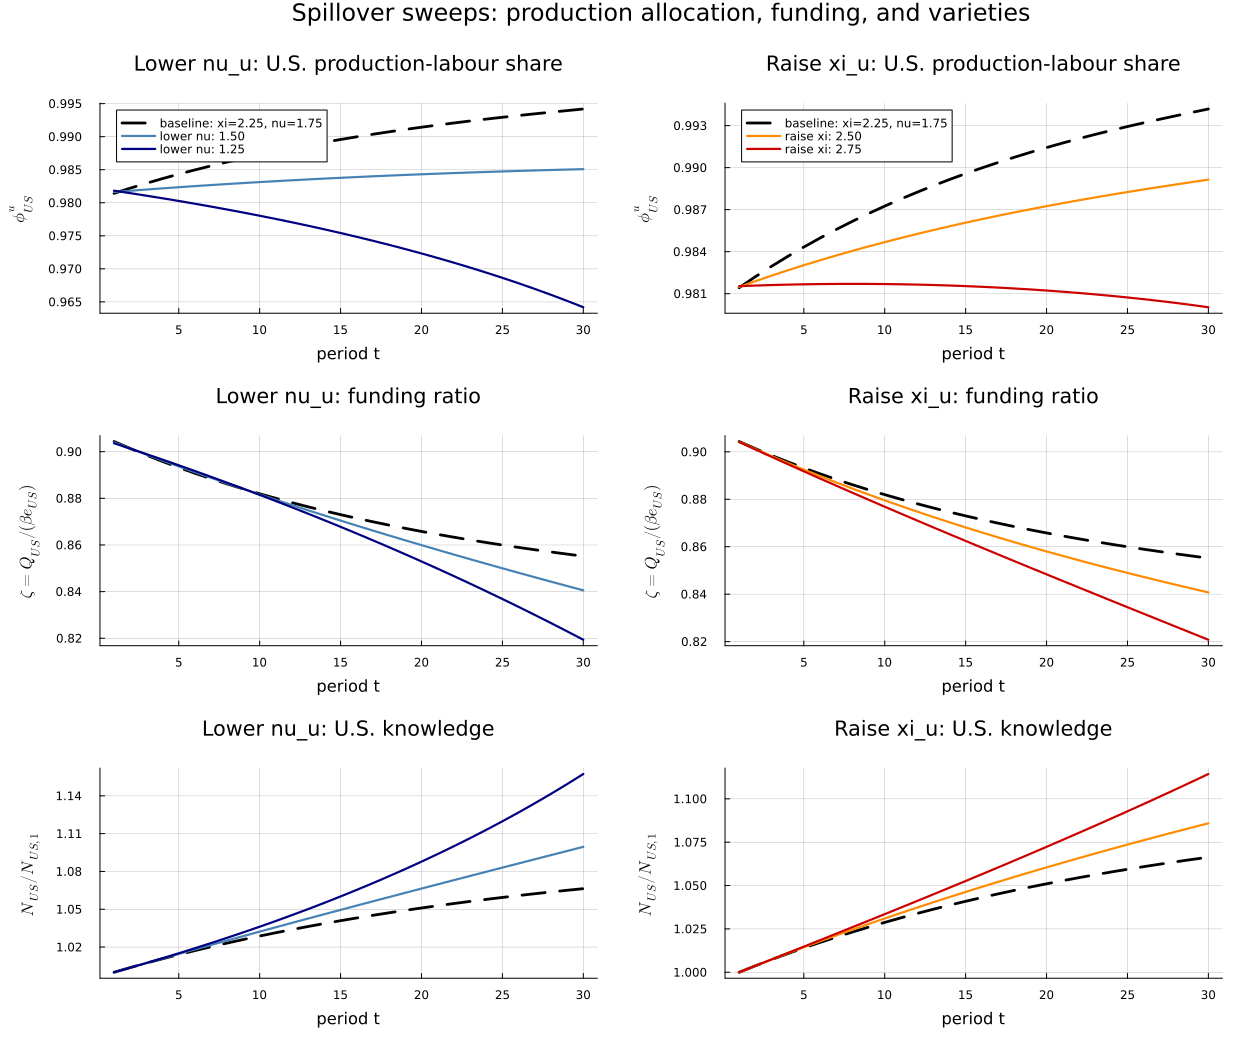

In [6]:
nu_diag = [d for d in nb04_diag if d.sweep in ("baseline", "lower_nu")]
xi_diag = [d for d in nb04_diag if d.sweep in ("baseline", "raise_xi")]
case_colors = Dict(
    "baseline"=>:black, "nu_1_50"=>:steelblue, "nu_1_25"=>:navy,
    "xi_2_50"=>:darkorange, "xi_2_75"=>:red3,
)

function nb04_path_panel(ds, getter; title, ylabel, normalize=false, legend=:best)
    p = plot(title=title, xlabel="period t", ylabel=ylabel, legend=legend, gridalpha=0.25)
    for d in ds
        y = getter(d)
        yplot = normalize ? y ./ first(y) : y
        plot!(p, d.t, yplot; lw=d.case_id=="baseline" ? 2.8 : 2.2,
            ls=d.case_id=="baseline" ? :dash : :solid, color=case_colors[d.case_id], label=d.label)
    end
    return p
end

p_nu_phi = nb04_path_panel(nu_diag, d->d.phi_us_u; title="Lower nu_u: U.S. production-labour share", ylabel=L"\phi^u_{US}")
p_xi_phi = nb04_path_panel(xi_diag, d->d.phi_us_u; title="Raise xi_u: U.S. production-labour share", ylabel=L"\phi^u_{US}")
p_nu_zeta = nb04_path_panel(nu_diag, d->d.zeta; title="Lower nu_u: funding ratio", ylabel=L"\zeta=Q_{US}/(\beta e_{US})", legend=false)
p_xi_zeta = nb04_path_panel(xi_diag, d->d.zeta; title="Raise xi_u: funding ratio", ylabel=L"\zeta=Q_{US}/(\beta e_{US})", legend=false)
p_nu_N = nb04_path_panel(nu_diag, d->d.N_us; title="Lower nu_u: U.S. knowledge", ylabel=L"N_{US}/N_{US,1}", normalize=true, legend=false)
p_xi_N = nb04_path_panel(xi_diag, d->d.N_us; title="Raise xi_u: U.S. knowledge", ylabel=L"N_{US}/N_{US,1}", normalize=true, legend=false)

fig_mechanism = plot(p_nu_phi, p_xi_phi, p_nu_zeta, p_xi_zeta, p_nu_N, p_xi_N;
    layout=(3,2), size=(1250,1050), margin=5Plots.mm, plot_title="Spillover sweeps: production allocation, funding, and varieties")
savefig(fig_mechanism, joinpath(NB04_OUTDIR, "mechanism_sweep_paths.png"))
fig_mechanism

## 5. All-`u` versus switch-to-`b` labour allocations

At date $t$, the dashed line is the absorbing equilibrium evaluated at the knowledge state inherited from the all-`u` history. With $\nu_b=\xi_W=0$, switch-state policies are invariant to the inherited knowledge level; per-variety prices and dividends, rather than policies, absorb the $1/N$ restatement.

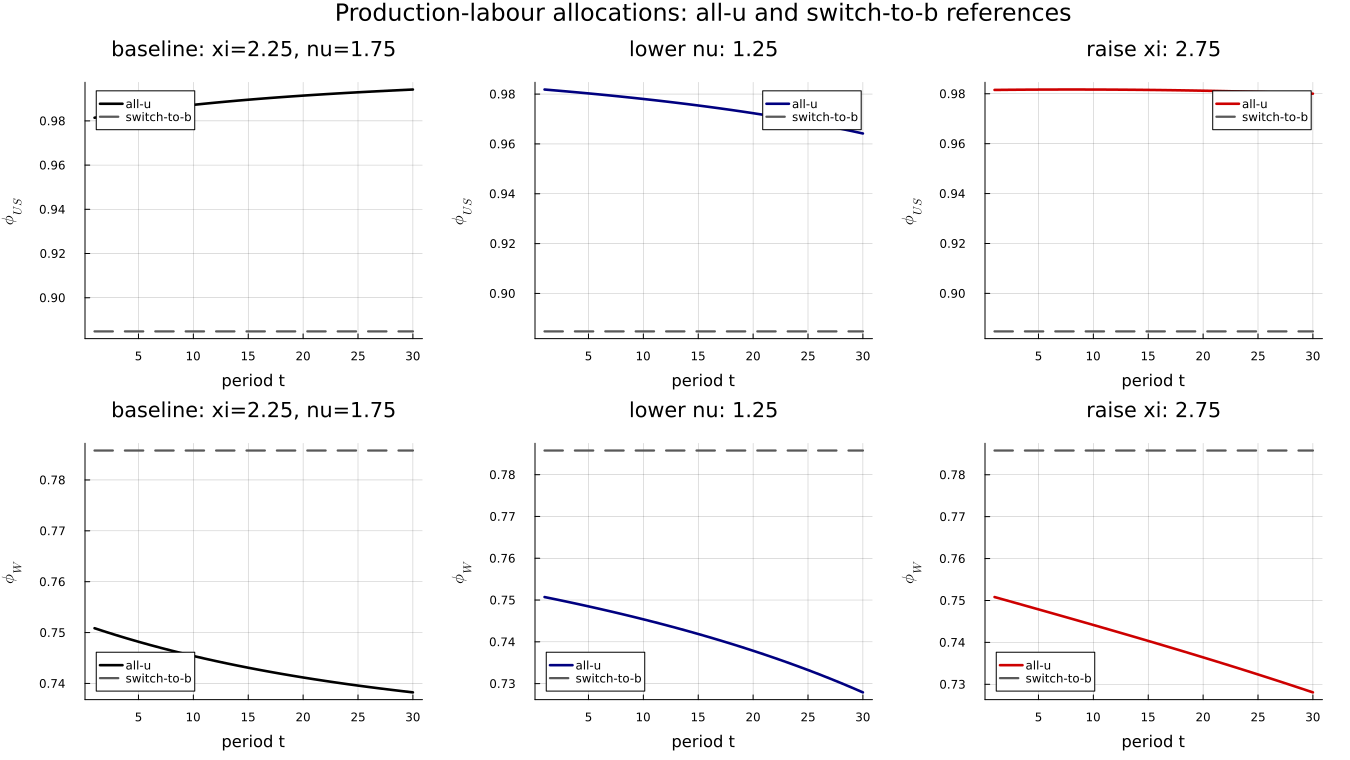

In [7]:
reference_ids = ["baseline", "nu_1_25", "xi_2_75"]
reference_diag = [only(filter(d->d.case_id==id, nb04_diag)) for id in reference_ids]
us_panels = Plots.Plot[]
w_panels = Plots.Plot[]
for d in reference_diag
    pus = plot(d.t, d.phi_us_u; lw=2.6, color=case_colors[d.case_id], label="all-u",
        xlabel="period t", ylabel=L"\phi_{US}", title=d.label, gridalpha=0.25)
    plot!(pus, d.t, d.phi_us_b; lw=2.3, ls=:dash, color=:gray35, label="switch-to-b")
    push!(us_panels, pus)

    pw = plot(d.t, d.phi_w_u; lw=2.6, color=case_colors[d.case_id], label="all-u",
        xlabel="period t", ylabel=L"\phi_W", title=d.label, gridalpha=0.25)
    plot!(pw, d.t, d.phi_w_b; lw=2.3, ls=:dash, color=:gray35, label="switch-to-b")
    push!(w_panels, pw)
end
fig_regime_phi = plot(vcat(us_panels, w_panels)...; layout=(2,3), size=(1350,760), margin=5Plots.mm,
    plot_title="Production-labour allocations: all-u and switch-to-b references")
savefig(fig_regime_phi, joinpath(NB04_OUTDIR, "all_u_vs_switch_to_b_phi_reference.png"))
fig_regime_phi

## 6. Endpoint decomposition and tail-exponent trade-off

A positive funding-ratio contribution means that falling $\zeta$ pushes $\phi^u_{US}$ upward. A negative production-composition contribution means that varieties and relative productivity push it downward. Lowering $\nu_u$ increases $\kappa_D$ but reduces $\kappa_S$; raising $\xi_u$ increases $\kappa_D$ without changing $\kappa_S$.

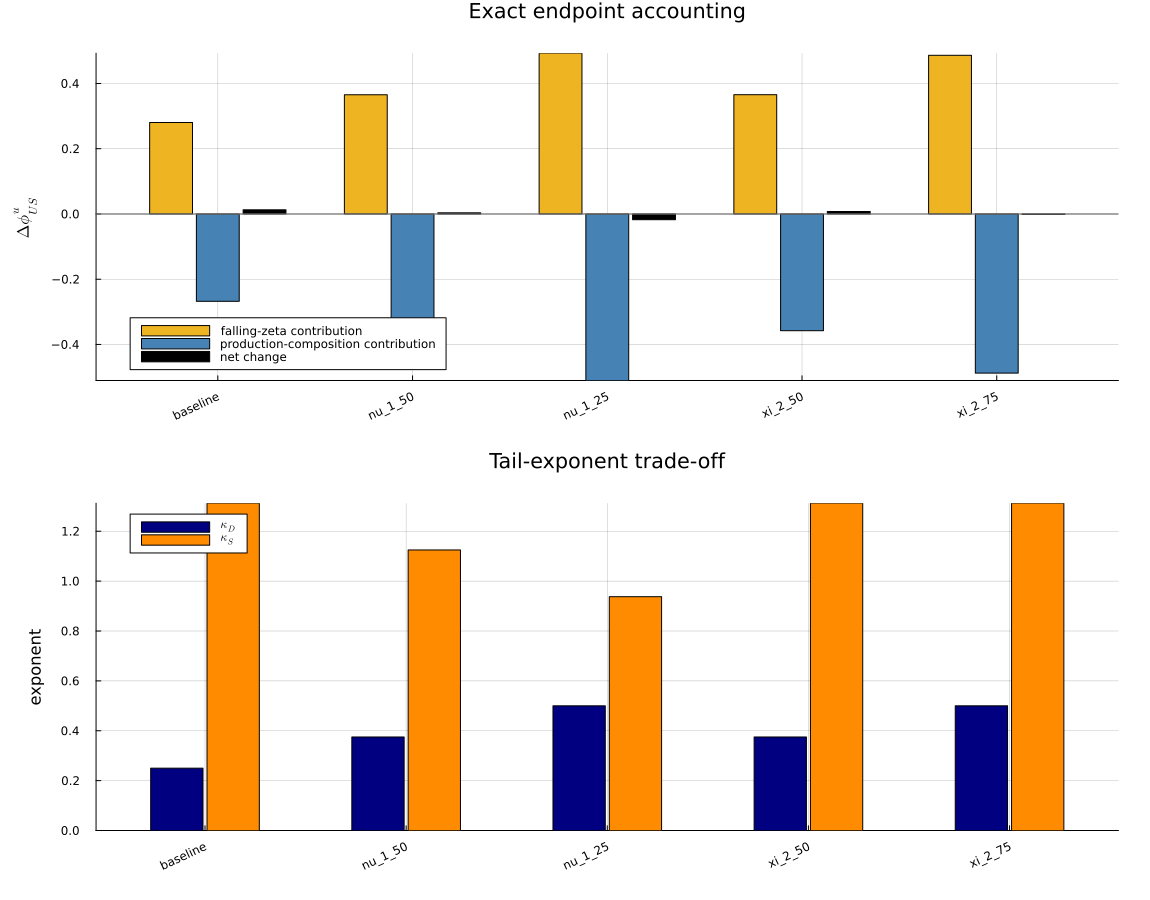

In [8]:
x = collect(1:length(nb04_diag))
labels = [d.case_id for d in nb04_diag]
funding = [d.funding_contribution for d in nb04_diag]
composition = [d.composition_contribution for d in nb04_diag]
net = [d.delta_phi for d in nb04_diag]

p_decomp = bar(x .- 0.24, funding; bar_width=0.22, label="falling-zeta contribution", color=:goldenrod2,
    xticks=(x, labels), xrotation=25, ylabel=L"\Delta\phi^u_{US}", title="Exact endpoint accounting", gridalpha=0.25)
bar!(p_decomp, x, composition; bar_width=0.22, label="production-composition contribution", color=:steelblue)
bar!(p_decomp, x .+ 0.24, net; bar_width=0.22, label="net change", color=:black)
hline!(p_decomp, [0.0]; color=:gray45, lw=1.2, label=false)

kD = [d.kappa_D for d in nb04_diag]
kS = [d.kappa_S for d in nb04_diag]
p_exponents = bar(x .- 0.14, kD; bar_width=0.26, label=L"\kappa_D", color=:navy,
    xticks=(x, labels), xrotation=25, ylabel="exponent", title="Tail-exponent trade-off", gridalpha=0.25)
bar!(p_exponents, x .+ 0.14, kS; bar_width=0.26, label=L"\kappa_S", color=:darkorange)

fig_decomp = plot(p_decomp, p_exponents; layout=(2,1), size=(1150,900), margin=6Plots.mm)
savefig(fig_decomp, joinpath(NB04_OUTDIR, "endpoint_decomposition_and_tail_exponents.png"))
fig_decomp

## 7. Verification and saved artifacts

In [9]:
manifest_rows = [
    (item="model_file", value=NB04_MODEL_FILE),
    (item="T_max", value=string(NB04_T)),
    (item="n_buffer", value="0"),
    (item="nu_b", value="0.0"),
    (item="xi_W", value="0.0"),
    (item="common_world_growth", value="false (inert compatibility metadata)"),
    (item="sweep_design", value="lower nu_u and raise xi_u separately"),
    (item="interpretation", value="finite-horizon comparative-static diagnostic; not theorem certification"),
]
nb04_write_csv(joinpath(NB04_OUTDIR, "run_manifest.csv"), manifest_rows, ["item", "value"])

@assert all(d->d.p.ν_b==0.0 && d.p.ξ_W==0.0, nb04_diag)
@assert all(d->d.residual_safe && d.phi_interior, nb04_diag)
@assert all(d->d.identity_error<=1e-10, nb04_diag)
@assert only(filter(d->d.case_id=="baseline", nb04_diag)).delta_phi > 0
@assert only(filter(d->d.case_id=="nu_1_25", nb04_diag)).delta_phi < 0
@assert only(filter(d->d.case_id=="xi_2_75", nb04_diag)).delta_phi < 0

println("Notebook 04 verification passed. Artifacts:")
for f in sort(readdir(NB04_OUTDIR))
    println("  ", joinpath(NB04_OUTDIR, f))
end

Notebook 04 verification passed. Artifacts:


  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_proudction_zero_nu_b/outputs_zero_nu_b/04_phi_spillover_funding_sweeps/all_u_vs_switch_to_b_phi_reference.png
  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_proudction_zero_nu_b/outputs_zero_nu_b/04_phi_spillover_funding_sweeps/endpoint_decomposition_and_tail_exponents.png
  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_proudction_zero_nu_b/outputs_zero_nu_b/04_phi_spillover_funding_sweeps/funding_identity_zero_vs_fixed_positive.png
  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_proudction_zero_nu_b/outputs_zero_nu_b/04_phi_spillover_funding_sweeps/funding_identity_zero_vs_fixed_positive_paths.csv
  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/

## 8. Funding decomposition: absorbing-exponent sweep

This sweep holds the unbalanced-regime calibration fixed and sets the absorbing/RoW exponents jointly to $\nu_b=\xi_W\in\{0,0.25,0.5,0.75,1\}$. The zero endpoint uses the specialized zero-exponent solver; every positive point uses the isolated fixed-exponent solver.

Adding the two stock-market-clearing equations gives

$$\zeta_t=1+A_t-B_t,\qquad A_t=\frac{s_W e^u_{W,t}}{\beta e^u_{US,t}},\qquad B_t=\frac{Q^u_{W,t}}{\beta e^u_{US,t}},$$

where $s_W=(\beta+\chi)/(1+\chi)$ is the RoW saving rate implemented by the model. Thus $A_t$ is RoW funding capacity relative to U.S. saving, while $B_t$ is the amount of that combined funding absorbed by RoW equity, again relative to U.S. saving. The remaining gap $A_t-B_t$ is the net foreign-funding contribution to the U.S. stock-funding ratio.

In [10]:
const NB04_FIXED_MODEL_CANDIDATES = unique(normpath.([
    joinpath(pwd(), "Two_country_proudction_fixed_nu_b", "TwoCountryProductionOLG.jl"),
    joinpath(pwd(), "Codes", "Two_country_proudction_fixed_nu_b", "TwoCountryProductionOLG.jl"),
    joinpath(dirname(NB04_CODES_ROOT), "Codes", "Two_country_proudction_fixed_nu_b", "TwoCountryProductionOLG.jl"),
    joinpath(NB04_CODES_ROOT, "Two_country_proudction_fixed_nu_b", "TwoCountryProductionOLG.jl"),
]))
nb04_fixed_model_idx = findfirst(isfile, NB04_FIXED_MODEL_CANDIDATES)
isnothing(nb04_fixed_model_idx) && error("Cannot find the fixed-nu-b solver. Checked:\n" * join(NB04_FIXED_MODEL_CANDIDATES, "\n"))
const NB04_FIXED_MODEL_FILE = NB04_FIXED_MODEL_CANDIDATES[nb04_fixed_model_idx]

module NB04FixedPositive
include(Main.NB04_FIXED_MODEL_FILE)
end

const NB04_ABSORBING_EXPONENT_GRID = [0.0, 0.25, 0.5, 0.75, 1.0]

function nb04_fixed_positive_params(exponent)
    @assert exponent > 0
    NB04FixedPositive.ProductionParams(
        T_max=NB04_T, n_buffer=0, branch_iters=NB04_BRANCH_ITERS,
        common_world_growth=false, do_global_polish=false,
        β=0.45, γ=0.25, π_persist=0.75,
        a_US=0.20, ϑ_US=0.85,
        a_W=0.06, H_W=3.0, L_W=3.0,
        A_X_US_u=15.0, A_L_US_u=1.5,
        ν_b=exponent, ν_u=1.75, ξ_u=2.25, ξ_W=exponent,
        ω̄=0.50, ω̄_star=0.25,
        κ=1.00, χ=0.0002, η=0.010,
    )
end

nb04_zero_result = nb04_solutions["baseline"]
nb04_fixed_results = Dict{Float64,Any}()
for exponent in NB04_ABSORBING_EXPONENT_GRID[2:end]
    @info "Solving fixed-positive sweep case" exponent NB04_FIXED_MODEL_FILE
    nb04_fixed_results[exponent] = NB04FixedPositive.run_production_simulation(
        nb04_fixed_positive_params(exponent); verbose=false)
end
nothing

┌ Info: Solving fixed-positive sweep case
│   exponent = 0.25
└   NB04_FIXED_MODEL_FILE = "/Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_proudction_fixed_nu_b/TwoCountryProductionOLG.jl"
┌ Info: Solving fixed-positive sweep case
│   exponent = 0.5
└   NB04_FIXED_MODEL_FILE = "/Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_proudction_fixed_nu_b/TwoCountryProductionOLG.jl"


┌ Info: Solving fixed-positive sweep case
│   exponent = 0.75
└   NB04_FIXED_MODEL_FILE = "/Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_proudction_fixed_nu_b/TwoCountryProductionOLG.jl"
┌ Info: Solving fixed-positive sweep case
│   exponent = 1.0
└   NB04_FIXED_MODEL_FILE = "/Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_proudction_fixed_nu_b/TwoCountryProductionOLG.jl"


In [11]:
function nb04_funding_identity(case_id, label, result)
    p = result.params
    u = result.u_path
    t = collect(1:length(u))
    s_W = (p.β + p.χ) / (1 + p.χ)
    A = Float64[s_W * s.e_W / (p.β * s.e_US) for s in u]
    B = Float64[s.Q_W / (p.β * s.e_US) for s in u]
    gap = A .- B
    zeta_direct = Float64[s.Q_US / (p.β * s.e_US) for s in u]
    zeta_rebuilt = 1 .+ gap
    identity_error = maximum(abs.(zeta_direct .- zeta_rebuilt))
    residual_safe = result.branch_converged &&
        isfinite(result.max_u_residual) && result.max_u_residual <= NB04_RESID_TOL &&
        isfinite(result.max_bgp_residual) && result.max_bgp_residual <= NB04_RESID_TOL
    return (; case_id, label, nu_b=p.ν_b, xi_W=p.ξ_W, t, A, B, gap,
        zeta_direct, zeta_rebuilt, s_W, identity_error, residual_safe, result)
end

nb04_funding_cases = [
    nb04_funding_identity("exp_0_00", "nu_b = xi_W = 0.00", nb04_zero_result),
    nb04_funding_identity("exp_0_25", "nu_b = xi_W = 0.25", nb04_fixed_results[0.25]),
    nb04_funding_identity("exp_0_50", "nu_b = xi_W = 0.50", nb04_fixed_results[0.50]),
    nb04_funding_identity("exp_0_75", "nu_b = xi_W = 0.75", nb04_fixed_results[0.75]),
    nb04_funding_identity("exp_1_00", "nu_b = xi_W = 1.00", nb04_fixed_results[1.00]),
]

@assert all(d->d.residual_safe, nb04_funding_cases)
@assert all(d->d.identity_error <= NB04_RESID_TOL, nb04_funding_cases)
@assert [d.nu_b for d in nb04_funding_cases] == NB04_ABSORBING_EXPONENT_GRID
@assert all(d->d.nu_b == d.xi_W, nb04_funding_cases)
nothing

In [12]:
funding_path_rows = NamedTuple[]
for d in nb04_funding_cases, j in eachindex(d.t)
    push!(funding_path_rows, (;
        case_id=d.case_id, nu_b=d.nu_b, xi_W=d.xi_W, t=d.t[j], s_W=d.s_W,
        A_t=d.A[j], B_t=d.B[j], A_t_minus_B_t=d.gap[j],
        zeta_direct=d.zeta_direct[j], zeta_rebuilt=d.zeta_rebuilt[j],
        identity_error=abs(d.zeta_direct[j]-d.zeta_rebuilt[j]),
    ))
end
funding_path_columns = String.(propertynames(first(funding_path_rows)))
nb04_write_csv(joinpath(NB04_OUTDIR, "funding_identity_zero_vs_fixed_positive_paths.csv"),
    funding_path_rows, funding_path_columns)

funding_summary_rows = [(;
    case_id=d.case_id, nu_b=d.nu_b, xi_W=d.xi_W,
    A_initial=first(d.A), A_final=last(d.A), delta_A=last(d.A)-first(d.A),
    B_initial=first(d.B), B_final=last(d.B), delta_B=last(d.B)-first(d.B),
    gap_initial=first(d.gap), gap_final=last(d.gap), delta_gap=last(d.gap)-first(d.gap),
    zeta_initial=first(d.zeta_direct), zeta_final=last(d.zeta_direct),
    max_identity_error=d.identity_error, residual_safe=d.residual_safe,
    max_u_residual=d.result.max_u_residual, max_bgp_residual=d.result.max_bgp_residual,
) for d in nb04_funding_cases]
funding_summary_columns = String.(propertynames(first(funding_summary_rows)))
nb04_write_csv(joinpath(NB04_OUTDIR, "funding_identity_zero_vs_fixed_positive_summary.csv"),
    funding_summary_rows, funding_summary_columns)

funding_table = [
    "| case | A: first to last | B: first to last | A-B: first to last | zeta: first to last | max identity error |",
    "|---|---:|---:|---:|---:|---:|",
]
for r in funding_summary_rows
    push!(funding_table, @sprintf("| %s | %.4f to %.4f | %.4f to %.4f | %+.4f to %+.4f | %.4f to %.4f | %.2e |",
        r.case_id, r.A_initial, r.A_final, r.B_initial, r.B_final,
        r.gap_initial, r.gap_final, r.zeta_initial, r.zeta_final, r.max_identity_error))
end
display(Markdown.parse(join(funding_table, "\n")))

|     case | A: first to last | B: first to last | A-B: first to last | zeta: first to last | max identity error |
| --------:| ----------------:| ----------------:| ------------------:| -------------------:| ------------------:|
| exp*0*00 | 1.8923 to 1.6830 | 1.9879 to 1.8278 | -0.0956 to -0.1448 |    0.9044 to 0.8552 |           8.51e-09 |
| exp*0*25 | 1.8919 to 1.9309 | 1.9950 to 2.0553 | -0.1031 to -0.1244 |    0.8969 to 0.8756 |           8.80e-09 |
| exp*0*50 | 1.8914 to 2.1468 | 2.0018 to 2.2475 | -0.1103 to -0.1006 |    0.8897 to 0.8994 |           8.62e-09 |
| exp*0*75 | 1.8910 to 2.3362 | 2.0082 to 2.4109 | -0.1172 to -0.0747 |    0.8828 to 0.9253 |           6.99e-09 |
| exp*1*00 | 1.8906 to 2.5035 | 2.0144 to 2.5503 | -0.1238 to -0.0468 |    0.8762 to 0.9532 |           7.33e-09 |


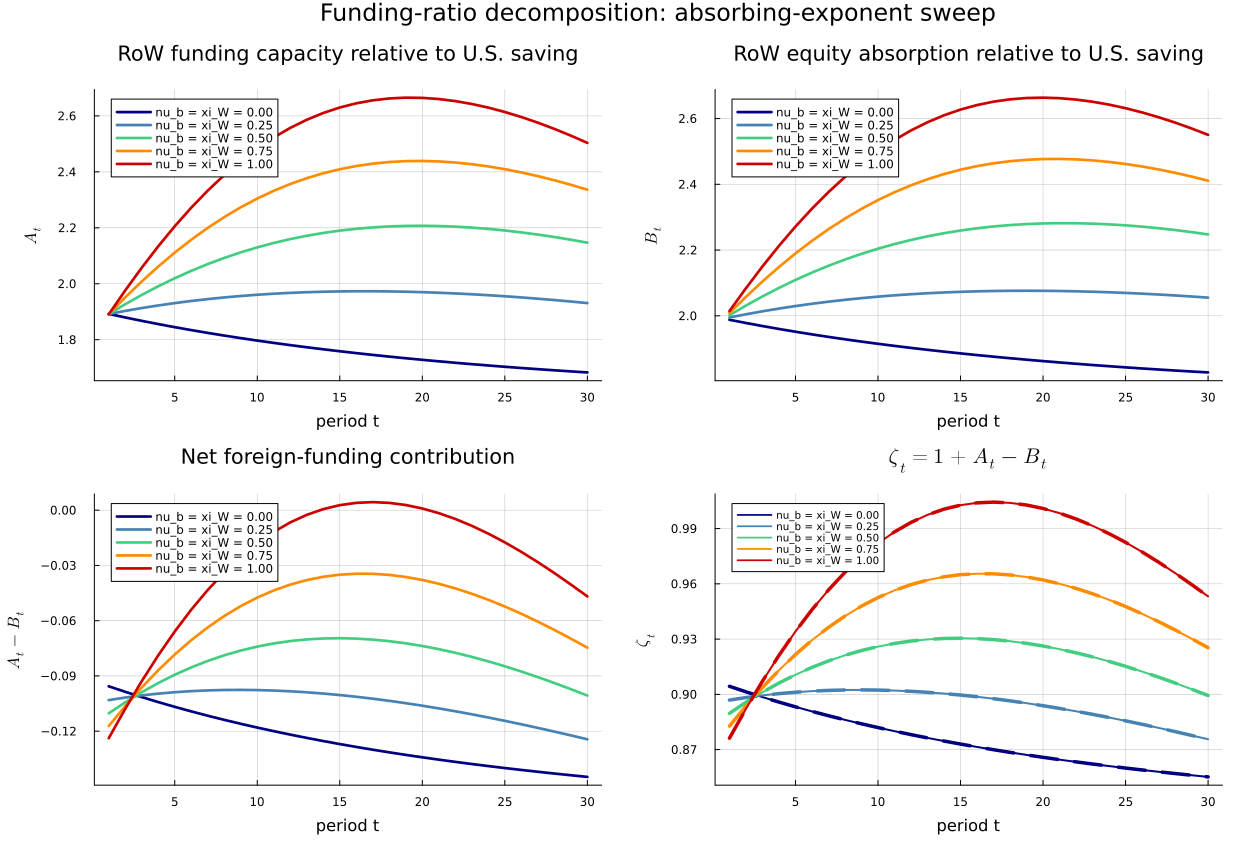

In [13]:
funding_colors = Dict(
    "exp_0_00"=>:navy, "exp_0_25"=>:steelblue, "exp_0_50"=>:seagreen3,
    "exp_0_75"=>:darkorange, "exp_1_00"=>:red3,
)
function nb04_sweep_panel(getter; title, ylabel, legend=:best)
    p = plot(title=title, xlabel="period t", ylabel=ylabel, legend=legend, legendfontsize=8, gridalpha=0.25)
    for d in nb04_funding_cases
        plot!(p, d.t, getter(d); lw=2.7, color=funding_colors[d.case_id], label=d.label)
    end
    return p
end

p_A = nb04_sweep_panel(d->d.A; title="RoW funding capacity relative to U.S. saving", ylabel=L"A_t")
p_B = nb04_sweep_panel(d->d.B; title="RoW equity absorption relative to U.S. saving", ylabel=L"B_t")
p_gap = nb04_sweep_panel(d->d.gap; title="Net foreign-funding contribution", ylabel=L"A_t-B_t")

p_identity = plot(title=L"\zeta_t=1+A_t-B_t", xlabel="period t", ylabel=L"\zeta_t", legendfontsize=7, gridalpha=0.25)
for d in nb04_funding_cases
    plot!(p_identity, d.t, d.zeta_rebuilt; lw=3.5, ls=:dash, color=funding_colors[d.case_id], label=false)
    plot!(p_identity, d.t, d.zeta_direct; lw=2.0, color=funding_colors[d.case_id], label=d.label)
end

fig_funding_identity = plot(p_A, p_B, p_gap, p_identity; layout=(2,2), size=(1250,850),
    margin=5Plots.mm, plot_title="Funding-ratio decomposition: absorbing-exponent sweep")
savefig(fig_funding_identity, joinpath(NB04_OUTDIR, "funding_identity_zero_vs_fixed_positive.png"))
fig_funding_identity

In [14]:
println("Absorbing-exponent funding decomposition verification passed.")
for d in nb04_funding_cases
    @printf("  %-14s nu_b=xi_W=%.2f  max identity error=%.3e  max u residual=%.3e\n",
        d.case_id, d.nu_b, d.identity_error, d.result.max_u_residual)
end
println("  Figure: ", joinpath(NB04_OUTDIR, "funding_identity_zero_vs_fixed_positive.png"))

Absorbing-exponent funding decomposition verification passed.
  exp_0_00       nu_b=xi_W=0.00  max identity error=8.508e-09  max u residual=1.032e-07
  exp_0_25       nu_b=xi_W=0.25  max identity error=8.799e-09  max u residual=1.148e-07
  exp_0_50       nu_b=xi_W=0.50  max identity error=8.616e-09  max u residual=1.240e-07
  exp_0_75       nu_b=xi_W=0.75  max identity error=6.994e-09  max u residual=1.159e-07
  exp_1_00       nu_b=xi_W=1.00  max identity error=7.327e-09  max u residual=1.312e-07
  Figure: /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_proudction_zero_nu_b/outputs_zero_nu_b/04_phi_spillover_funding_sweeps/funding_identity_zero_vs_fixed_positive.png


## 9. Relative-scale versus RoW-capitalization decomposition

Equivalently, define

$$m_t=\frac{e^u_{W,t}}{e^u_{US,t}},\qquad \mu_t=\frac{Q^u_{W,t}}{e^u_{W,t}}.$$

Then the funding identity becomes

$$\zeta_t=1+\frac{m_t}{\beta}(s_W-\mu_t).$$

The factor $m_t/\beta$ measures the relative scale of RoW resources, while $s_W-\mu_t$ measures RoW saving net of RoW equity capitalization per unit of RoW labour income. The exact endpoint product decomposition below assigns the change in $\zeta_t$ to the change in relative scale and the change in the capitalization wedge. This remains an all-`u` accounting decomposition; it does not by itself identify the separate `u`-to-`b` payoff channel.

In [15]:
function nb04_relative_scale_identity(d)
    p = d.result.params
    u = d.result.u_path
    m = Float64[s.e_W / s.e_US for s in u]
    mu = Float64[s.Q_W / s.e_W for s in u]
    scale = m ./ p.β
    wedge = d.s_W .- mu
    contribution = scale .* wedge
    zeta_rebuilt = 1 .+ contribution
    identity_error = maximum(abs.(d.zeta_direct .- zeta_rebuilt))

    scale_bar = (first(scale) + last(scale)) / 2
    wedge_bar = (first(wedge) + last(wedge)) / 2
    relative_scale_contribution = wedge_bar * (last(scale) - first(scale))
    capitalization_contribution = scale_bar * (last(wedge) - first(wedge))
    net_change = last(contribution) - first(contribution)

    return (; d.case_id, d.label, d.nu_b, d.xi_W, d.t, d.s_W, d.zeta_direct,
        m, mu, scale, wedge, contribution, zeta_rebuilt, identity_error,
        relative_scale_contribution, capitalization_contribution, net_change,
        result=d.result)
end

nb04_relative_cases = nb04_relative_scale_identity.(nb04_funding_cases)
for d in nb04_relative_cases
    @assert d.identity_error <= NB04_RESID_TOL
    @assert abs(d.net_change - d.relative_scale_contribution - d.capitalization_contribution) <= 1e-12
end
nothing

In [16]:
relative_path_rows = NamedTuple[]
for d in nb04_relative_cases, j in eachindex(d.t)
    push!(relative_path_rows, (;
        case_id=d.case_id, nu_b=d.nu_b, xi_W=d.xi_W, t=d.t[j], s_W=d.s_W,
        m_t=d.m[j], mu_t=d.mu[j], m_over_beta=d.scale[j],
        s_W_minus_mu_t=d.wedge[j], zeta_minus_one=d.contribution[j],
        zeta_direct=d.zeta_direct[j], zeta_rebuilt=d.zeta_rebuilt[j],
        identity_error=abs(d.zeta_direct[j]-d.zeta_rebuilt[j]),
    ))
end
relative_path_columns = String.(propertynames(first(relative_path_rows)))
nb04_write_csv(joinpath(NB04_OUTDIR, "relative_scale_capitalization_paths.csv"),
    relative_path_rows, relative_path_columns)

relative_summary_rows = [(;
    case_id=d.case_id, nu_b=d.nu_b, xi_W=d.xi_W,
    m_initial=first(d.m), m_final=last(d.m), delta_m=last(d.m)-first(d.m),
    mu_initial=first(d.mu), mu_final=last(d.mu), delta_mu=last(d.mu)-first(d.mu),
    wedge_initial=first(d.wedge), wedge_final=last(d.wedge),
    relative_scale_contribution=d.relative_scale_contribution,
    capitalization_contribution=d.capitalization_contribution,
    net_change_zeta=d.net_change, max_identity_error=d.identity_error,
) for d in nb04_relative_cases]
relative_summary_columns = String.(propertynames(first(relative_summary_rows)))
nb04_write_csv(joinpath(NB04_OUTDIR, "relative_scale_capitalization_summary.csv"),
    relative_summary_rows, relative_summary_columns)

relative_table = [
    "| case | m: first to last | mu: first to last | scale contribution | capitalization contribution | net change in zeta |",
    "|---|---:|---:|---:|---:|---:|",
]
for r in relative_summary_rows
    push!(relative_table, @sprintf("| %s | %.4f to %.4f | %.4f to %.4f | %+.5f | %+.5f | %+.5f |",
        r.case_id, r.m_initial, r.m_final, r.mu_initial, r.mu_final,
        r.relative_scale_contribution, r.capitalization_contribution, r.net_change_zeta))
end
display(Markdown.parse(join(relative_table, "\n")))

|     case | m: first to last | mu: first to last | scale contribution | capitalization contribution | net change in zeta |
| --------:| ----------------:| -----------------:| ------------------:| ---------------------------:| ------------------:|
| exp*0*00 | 1.8918 to 1.6826 |  0.4729 to 0.4888 |           +0.01429 |                    -0.06348 |           -0.04919 |
| exp*0*25 | 1.8914 to 1.9305 |  0.4746 to 0.4791 |           -0.00232 |                    -0.01896 |           -0.02128 |
| exp*0*50 | 1.8910 to 2.1463 |  0.4764 to 0.4712 |           -0.01343 |                    +0.02310 |           +0.00967 |
| exp*0*75 | 1.8906 to 2.3356 |  0.4780 to 0.4645 |           -0.02091 |                    +0.06345 |           +0.04254 |
| exp*1*00 | 1.8902 to 2.5029 |  0.4796 to 0.4585 |           -0.02580 |                    +0.10278 |           +0.07698 |


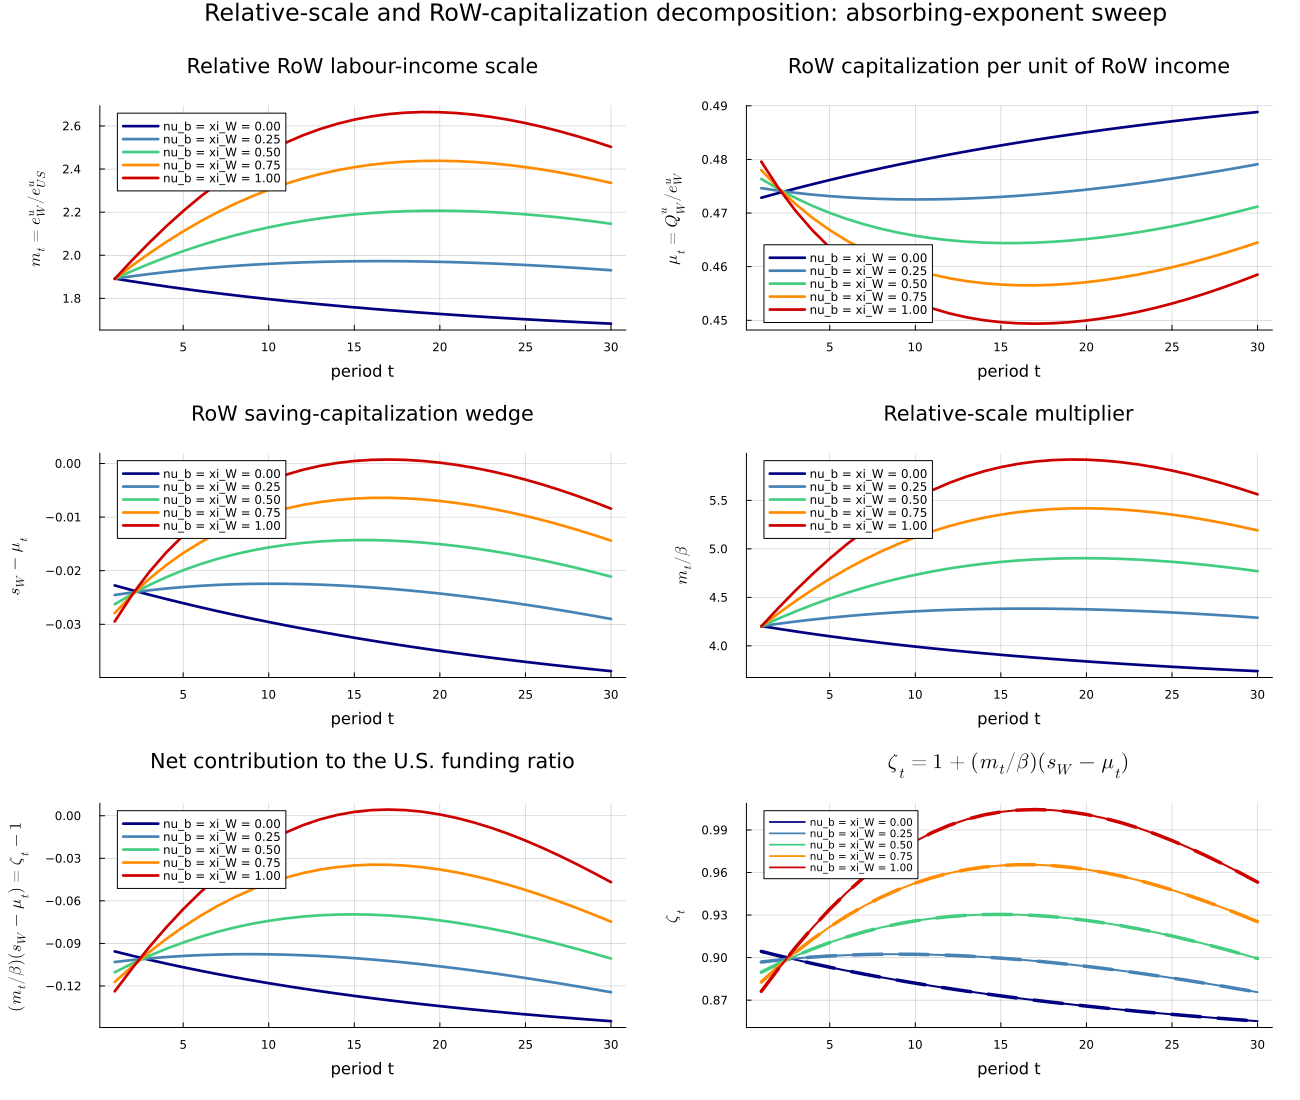

In [17]:
function nb04_relative_panel(getter; title, ylabel, legend=:best)
    p = plot(title=title, xlabel="period t", ylabel=ylabel, legend=legend, legendfontsize=8, gridalpha=0.25)
    for d in nb04_relative_cases
        plot!(p, d.t, getter(d); lw=2.7, color=funding_colors[d.case_id], label=d.label)
    end
    return p
end

p_m = nb04_relative_panel(d->d.m; title="Relative RoW labour-income scale", ylabel=L"m_t=e^u_W/e^u_{US}")
p_mu = nb04_relative_panel(d->d.mu; title="RoW capitalization per unit of RoW income", ylabel=L"\mu_t=Q^u_W/e^u_W")
p_wedge = nb04_relative_panel(d->d.wedge; title="RoW saving-capitalization wedge", ylabel=L"s_W-\mu_t")
p_scale = nb04_relative_panel(d->d.scale; title="Relative-scale multiplier", ylabel=L"m_t/\beta")
p_product = nb04_relative_panel(d->d.contribution; title="Net contribution to the U.S. funding ratio", ylabel=L"(m_t/\beta)(s_W-\mu_t)=\zeta_t-1")

p_relative_identity = plot(title=L"\zeta_t=1+(m_t/\beta)(s_W-\mu_t)",
    xlabel="period t", ylabel=L"\zeta_t", legendfontsize=7, gridalpha=0.25)
for d in nb04_relative_cases
    plot!(p_relative_identity, d.t, d.zeta_rebuilt; lw=3.5, ls=:dash, color=funding_colors[d.case_id], label=false)
    plot!(p_relative_identity, d.t, d.zeta_direct; lw=2.0, color=funding_colors[d.case_id], label=d.label)
end

fig_relative_scale = plot(p_m, p_mu, p_wedge, p_scale, p_product, p_relative_identity;
    layout=(3,2), size=(1300,1100), margin=5Plots.mm,
    plot_title="Relative-scale and RoW-capitalization decomposition: absorbing-exponent sweep")
savefig(fig_relative_scale, joinpath(NB04_OUTDIR, "relative_scale_capitalization_zero_vs_fixed_positive.png"))
fig_relative_scale

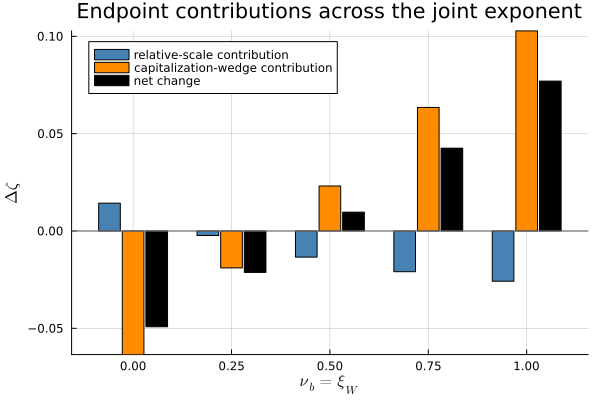

In [18]:
rx = collect(1:length(nb04_relative_cases))
rlabels = [@sprintf("%.2f", d.nu_b) for d in nb04_relative_cases]
rscale = [d.relative_scale_contribution for d in nb04_relative_cases]
rcap = [d.capitalization_contribution for d in nb04_relative_cases]
rnet = [d.net_change for d in nb04_relative_cases]

p_relative_endpoint = bar(rx .- 0.24, rscale; bar_width=0.22, color=:steelblue,
    label="relative-scale contribution", xticks=(rx, rlabels),
    xlabel=L"\nu_b=\xi_W", ylabel=L"\Delta\zeta",
    title="Endpoint contributions across the joint exponent", gridalpha=0.25)
bar!(p_relative_endpoint, rx, rcap; bar_width=0.22, color=:darkorange, label="capitalization-wedge contribution")
bar!(p_relative_endpoint, rx .+ 0.24, rnet; bar_width=0.22, color=:black, label="net change")
hline!(p_relative_endpoint, [0.0]; color=:gray45, lw=1.2, label=false)
savefig(p_relative_endpoint, joinpath(NB04_OUTDIR, "relative_scale_capitalization_endpoint_decomposition.png"))
p_relative_endpoint

In [19]:
println("Relative-scale/capitalization decomposition verification passed.")
for d in nb04_relative_cases
    @printf("  %-14s scale=%+.5f  capitalization=%+.5f  net delta zeta=%+.5f  identity=%.3e\n",
        d.case_id, d.relative_scale_contribution, d.capitalization_contribution, d.net_change, d.identity_error)
end

Relative-scale/capitalization decomposition verification passed.
  exp_0_00       scale=+0.01429  capitalization=-0.06348  net delta zeta=-0.04919  identity=8.508e-09
  exp_0_25       scale=-0.00232  capitalization=-0.01896  net delta zeta=-0.02128  identity=8.799e-09


  exp_0_50       scale=-0.01343  capitalization=+0.02310  net delta zeta=+0.00967  identity=8.616e-09
  exp_0_75       scale=-0.02091  capitalization=+0.06345  net delta zeta=+0.04254  identity=6.994e-09
  exp_1_00       scale=-0.02580  capitalization=+0.10278  net delta zeta=+0.07698  identity=7.327e-09


## 10. All-$u$ continuation and switch-to-$b$ state paths for the absorbing-exponent sweep

For every $\nu_b=\xi_W\in\{0,0.25,0.5,0.75,1\}$, the solid five-color comparison is repeated for 20 regime-country-quantity objects: two regimes, five quantities $(\phi,e,Q,q,N)$, and two countries. Here

- **$u$ continues to $u$** uses `result.u_path[t]`;
- **switch to $b$** uses `result.bgp_seq[t]`, the absorbing equilibrium evaluated at the same date-$t$ knowledge state inherited from the all-$u$ history.

The plotted valuation objects satisfy $Q_{i,t}=N_{i,t+1}q_{i,t}=G_{N_i,t}N_{i,t}q_{i,t}$. Knowledge is predetermined at the regime choice, so $N^{u\to b}_{i,t}=N^u_{i,t}$ by construction; the two $N$ rows are intentionally identical and verify the timing rather than introduce a second knowledge law. Levels of $e,Q,q,$ and $N$ are shown on logarithmic axes; $\phi$ remains on a linear axis.

In [20]:
const NB04_REGIME_SPECS = [
    (key=:phi, name="production-labour share", us_field=:φ_US, w_field=:φ_W,
        u_label=L"\phi^u_{i,t}", b_label=L"\phi^b_{i,t}", logscale=false),
    (key=:e, name="household labour income", us_field=:e_US, w_field=:e_W,
        u_label=L"e^u_{i,t}", b_label=L"e^b_{i,t}", logscale=true),
    (key=:Q, name="aggregate equity value", us_field=:Q_US, w_field=:Q_W,
        u_label=L"Q^u_{i,t}", b_label=L"Q^b_{i,t}", logscale=true),
    (key=:q, name="per-variety equity price", us_field=:q_US, w_field=:q_W,
        u_label=L"q^u_{i,t}", b_label=L"q^b_{i,t}", logscale=true),
    (key=:N, name="knowledge stock / varieties", us_field=:N_US, w_field=:N_W,
        u_label=L"N^u_{i,t}", b_label=L"N^{u\to b}_{i,t}", logscale=true),
]

nb04_regime_cases = [(; case_id=d.case_id, label=d.label, nu_b=d.nu_b, xi_W=d.xi_W,
    t=d.t, u=d.result.u_path, b=d.result.bgp_seq[1:length(d.t)], result=d.result)
    for d in nb04_funding_cases]

for d in nb04_regime_cases
    @assert length(d.u) == length(d.b) == NB04_T
    inherited_state_error = max(
        maximum(abs.(Float64[s.N_US for s in d.u] .- Float64[s.N_US for s in d.b])),
        maximum(abs.(Float64[s.N_W for s in d.u] .- Float64[s.N_W for s in d.b])),
    )
    @assert inherited_state_error <= 1e-12
    for states in (d.u, d.b), spec in NB04_REGIME_SPECS, field in (spec.us_field, spec.w_field)
        values = Float64[getproperty(s, field) for s in states]
        @assert all(x->isfinite(x) && x > 0, values)
    end
end
@assert 2 * length(NB04_REGIME_SPECS) * 2 == 20
nothing

In [21]:
regime_path_rows = NamedTuple[]
for d in nb04_regime_cases, j in eachindex(d.t)
    u, b = d.u[j], d.b[j]
    push!(regime_path_rows, (;
        case_id=d.case_id, nu_b=d.nu_b, xi_W=d.xi_W, t=d.t[j],
        phi_US_all_u=u.φ_US, phi_W_all_u=u.φ_W,
        e_US_all_u=u.e_US, e_W_all_u=u.e_W,
        Q_US_all_u=u.Q_US, Q_W_all_u=u.Q_W,
        q_US_all_u=u.q_US, q_W_all_u=u.q_W,
        N_US_all_u=u.N_US, N_W_all_u=u.N_W,
        phi_US_switch_to_b=b.φ_US, phi_W_switch_to_b=b.φ_W,
        e_US_switch_to_b=b.e_US, e_W_switch_to_b=b.e_W,
        Q_US_switch_to_b=b.Q_US, Q_W_switch_to_b=b.Q_W,
        q_US_switch_to_b=b.q_US, q_W_switch_to_b=b.q_W,
        N_US_switch_to_b=b.N_US, N_W_switch_to_b=b.N_W,
    ))
end
regime_path_columns = String.(propertynames(first(regime_path_rows)))
nb04_write_csv(joinpath(NB04_OUTDIR, "all_u_and_switch_to_b_state_paths.csv"),
    regime_path_rows, regime_path_columns)
nothing

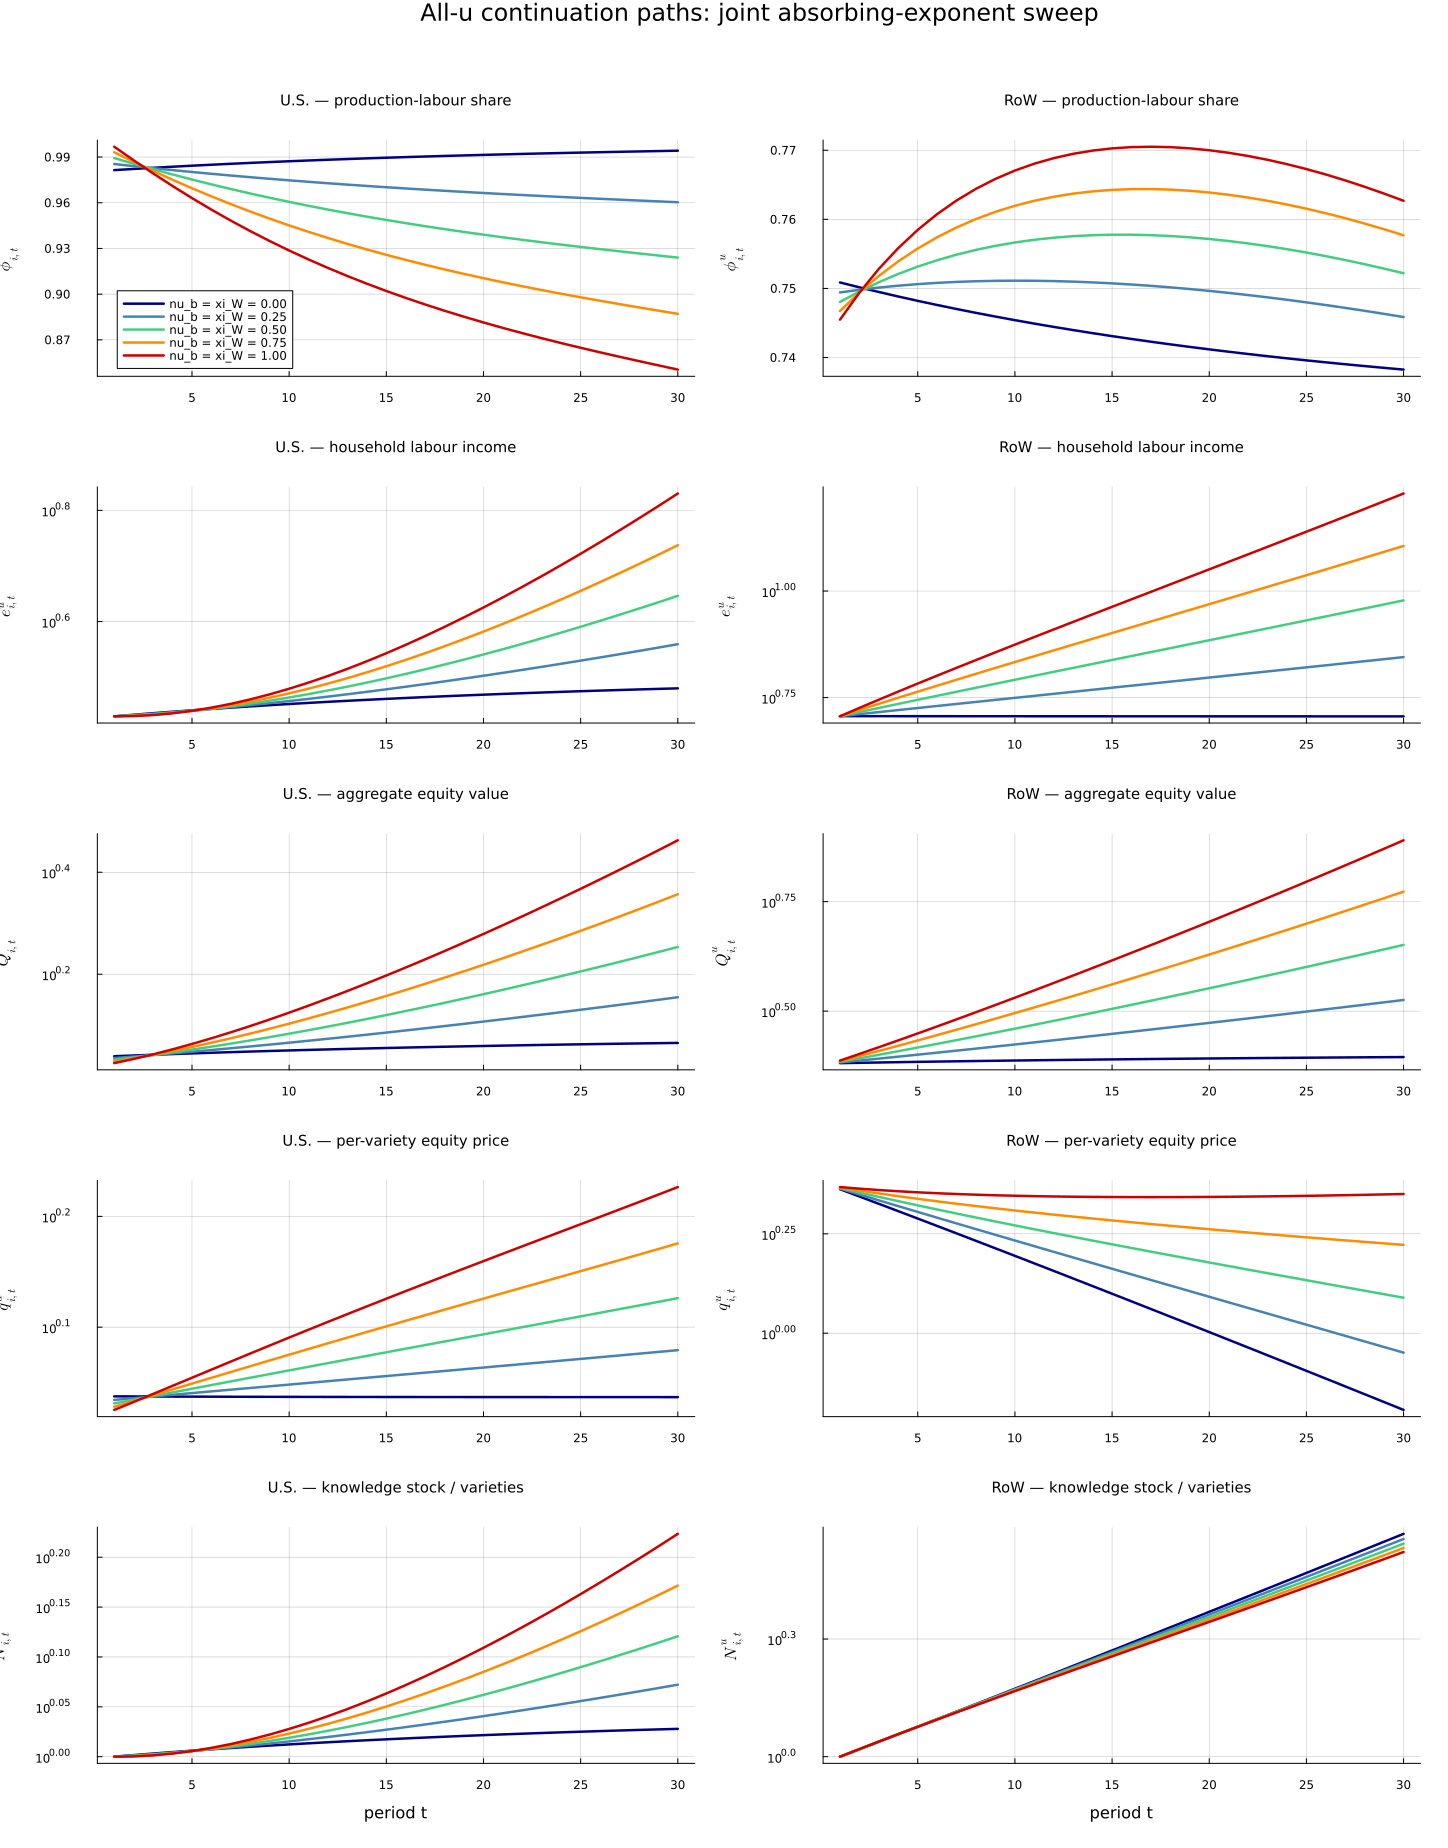

In [22]:
function nb04_regime_grid(regime::Symbol)
    @assert regime in (:u, :b)
    panels = Plots.Plot[]
    for (row, spec) in enumerate(NB04_REGIME_SPECS), country in (:US, :W)
        field = country === :US ? spec.us_field : spec.w_field
        country_label = country === :US ? "U.S." : "RoW"
        ylabel = regime === :u ? spec.u_label : spec.b_label
        p = plot(; title=country_label * " — " * spec.name, titlefontsize=10,
            xlabel=row == length(NB04_REGIME_SPECS) ? "period t" : "",
            ylabel=ylabel, yscale=spec.logscale ? :log10 : :identity,
            legend=(row == 1 && country === :US) ? :best : false,
            legendfontsize=8, gridalpha=0.25)
        for d in nb04_regime_cases
            states = regime === :u ? d.u : d.b
            values = Float64[getproperty(s, field) for s in states]
            plot!(p, d.t, values; lw=2.5, color=funding_colors[d.case_id], label=d.label)
        end
        push!(panels, p)
    end
    regime_title = regime === :u ?
        "All-u continuation paths: joint absorbing-exponent sweep" :
        "Switch-to-b paths at all-u inherited states: joint absorbing-exponent sweep"
    return plot(panels...; layout=(5,2), size=(1450,1850), margin=5Plots.mm,
        plot_title=regime_title)
end

fig_all_u_state_paths = nb04_regime_grid(:u)
savefig(fig_all_u_state_paths, joinpath(NB04_OUTDIR, "all_u_state_paths_absorbing_exponent_sweep.png"))
fig_all_u_state_paths

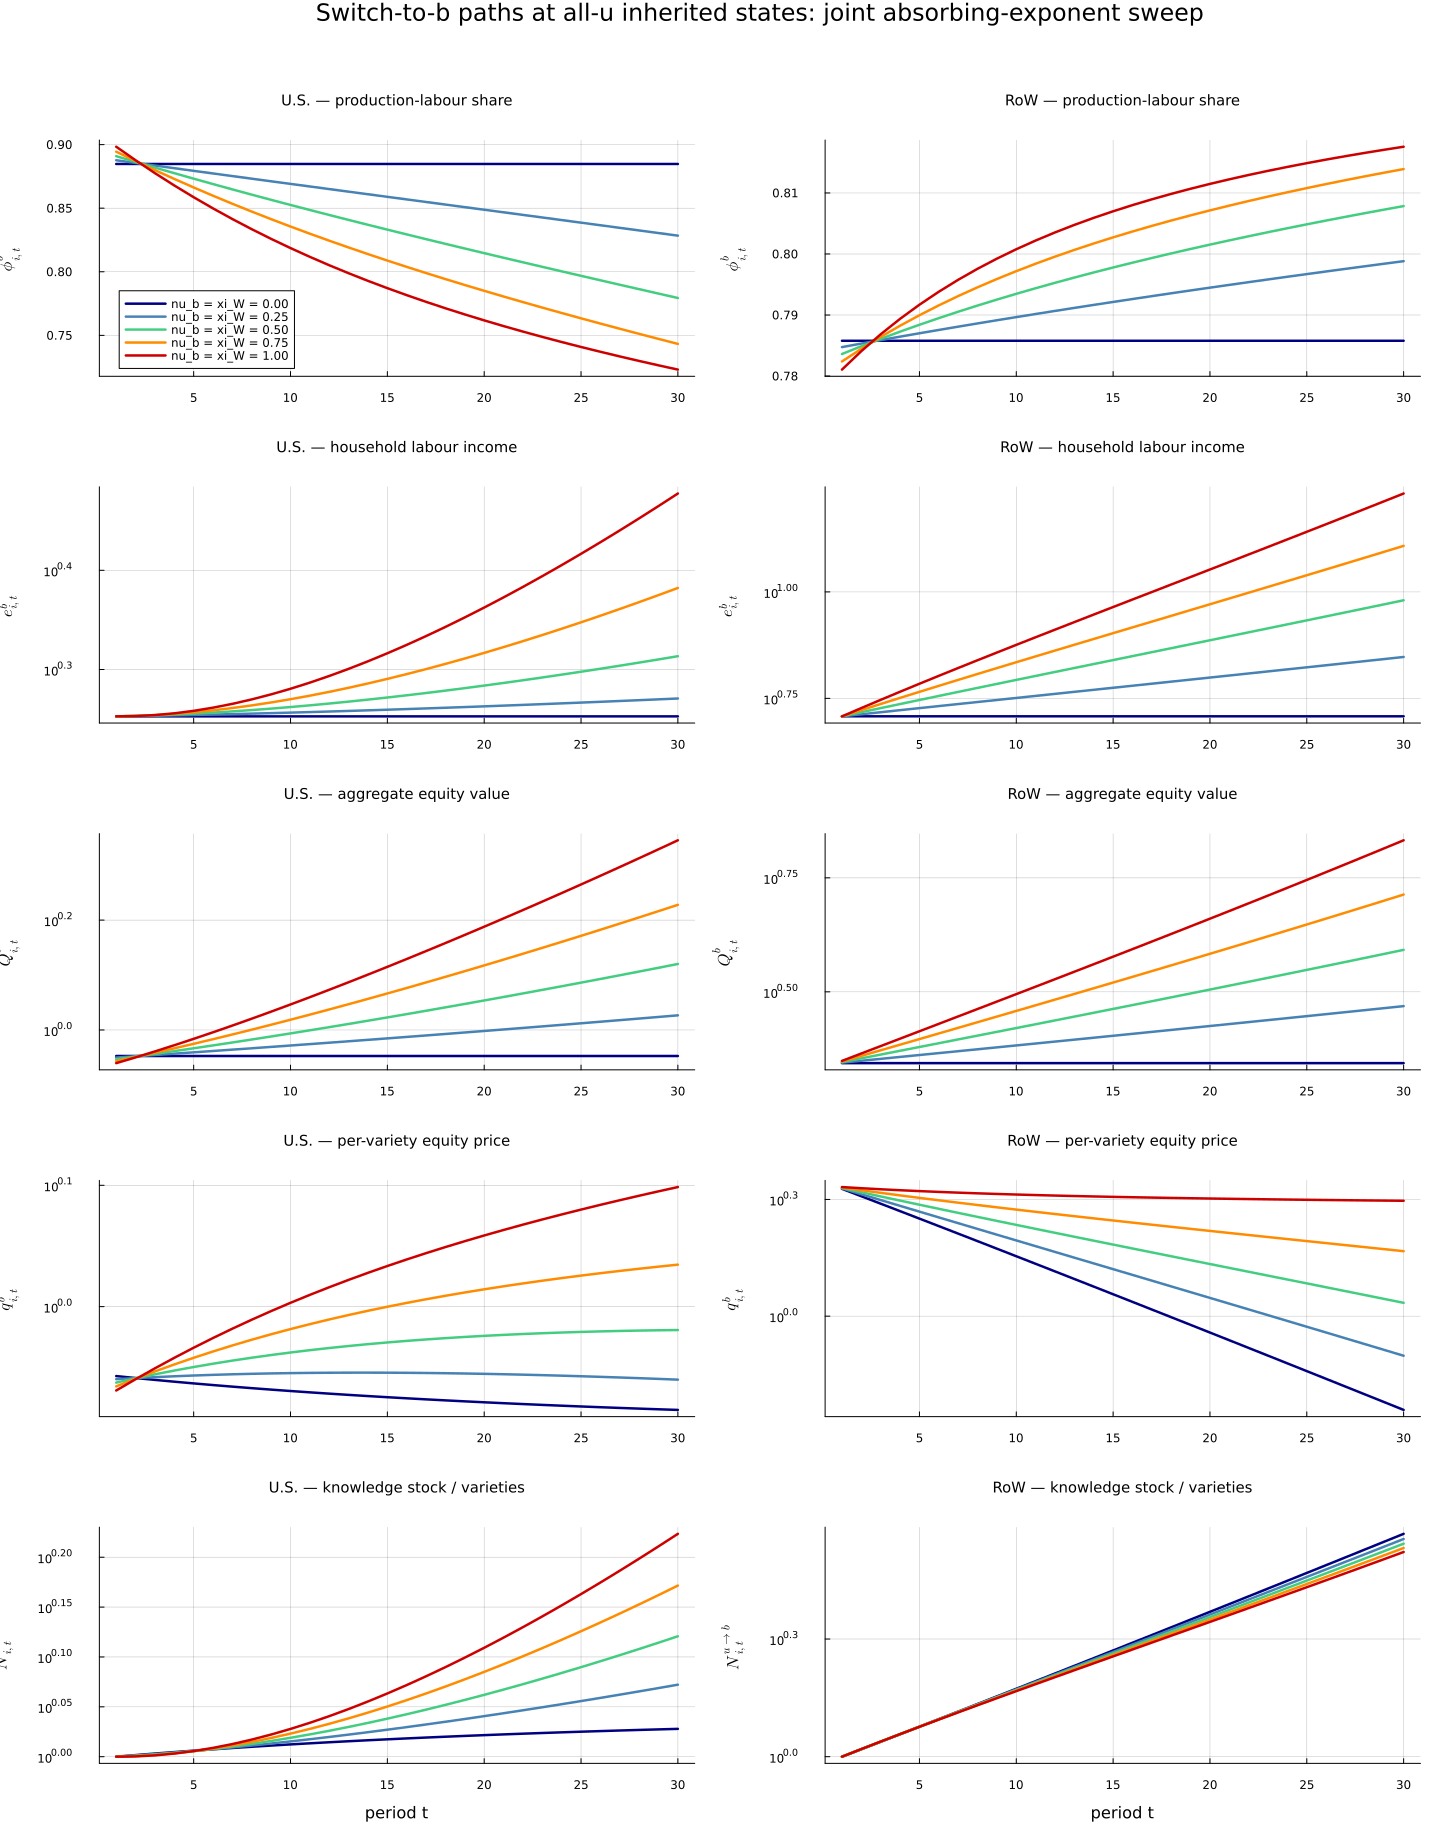

In [23]:
fig_switch_to_b_state_paths = nb04_regime_grid(:b)
savefig(fig_switch_to_b_state_paths, joinpath(NB04_OUTDIR, "switch_to_b_state_paths_absorbing_exponent_sweep.png"))
fig_switch_to_b_state_paths

In [24]:
joint_sweep_manifest_rows = vcat(manifest_rows, [
    (item="absorbing_exponent_sweep", value="nu_b = xi_W in {0, 0.25, 0.5, 0.75, 1}"),
    (item="regime_path_timing", value="u_path[t] versus bgp_seq[t] at common inherited knowledge state"),
    (item="regime_path_variables", value="phi, e, Q, q, N for US and RoW in both regimes (20 objects)"),
])
nb04_write_csv(joinpath(NB04_OUTDIR, "run_manifest.csv"),
    joint_sweep_manifest_rows, ["item", "value"])

println("Twenty-variable regime-path sweep verification passed.")
println("  cases: ", length(nb04_regime_cases), "; periods per case: ", NB04_T)
println("  raw-path rows: ", length(regime_path_rows), "; plotted objects: ",
    2 * length(NB04_REGIME_SPECS) * 2)
println("  Figures:")
println("    ", joinpath(NB04_OUTDIR, "all_u_state_paths_absorbing_exponent_sweep.png"))
println("    ", joinpath(NB04_OUTDIR, "switch_to_b_state_paths_absorbing_exponent_sweep.png"))
println("  Data: ", joinpath(NB04_OUTDIR, "all_u_and_switch_to_b_state_paths.csv"))

Twenty-variable regime-path sweep verification passed.
  cases: 5; periods per case: 30
  raw-path rows: 150; plotted objects: 20
  Figures:
    /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_proudction_zero_nu_b/outputs_zero_nu_b/04_phi_spillover_funding_sweeps/all_u_state_paths_absorbing_exponent_sweep.png
    /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_proudction_zero_nu_b/outputs_zero_nu_b/04_phi_spillover_funding_sweeps/switch_to_b_state_paths_absorbing_exponent_sweep.png
  Data: /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_proudction_zero_nu_b/outputs_zero_nu_b/04_phi_spillover_funding_sweeps/all_u_and_switch_to_b_state_paths.csv
